# Querying nodes using labels

Identifying subsets of nodes is a common task when analysing spatial networks. For example, you may wish to compute a statistic using only a subset of nodes or extract nodes that satisfy a particular condition, such as having a specific label or attribute.

In this tutorial, we'll demonstrate how to identify node IDs using the `query_nodes()` function. We'll begin by loading the example spiral dataset and assigning categorical labels to its nodes.

(<Figure size 640x480 with 2 Axes>, <Axes: >)

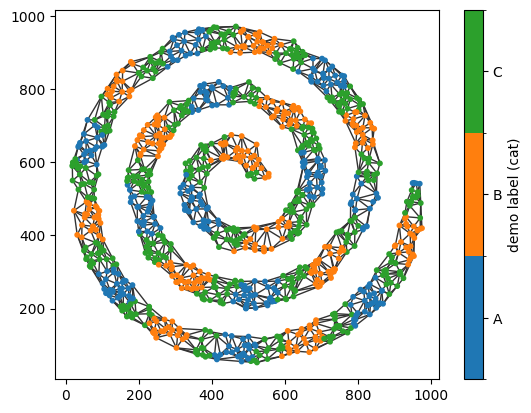

In [1]:
import spacenet as sn
import numpy as np

# load in the example dataset 'sprial'
spiral_data = sn.datasets.load_dataset('spiral')

# extract the point data
points = np.array([spiral_data['x'],spiral_data['y']]).T

# extract the categorical labels 
cat_labels = spiral_data['Marker (categorical)']

# generate a spatial network
spatial_net = sn.utils.spatial_network_from_points(points,max_edge_distance=75)

# add the categorical labels to the network
sn.utils.add_node_labels(spatial_net,labels=cat_labels,node_label_name='demo label (cat)')

# plot the spatial network with nodes colored by the demo labels 
sn.utils.plot_spatial_network(spatial_net,node_label_name='demo label (cat)')

We now have a spatial network with the categorical node labels `demo label (cat)`. Let's use `query_nodes()` to retrieve the IDs of all nodes whose label is `A`.

The `query_nodes()` function has three key parameters:

* `node_label_name`: the name of the node label to query.
* `relation`: the comparison operation to apply (e.g. `equals`, `in`, `greater_than`).
* `node_label_value`: the target value or values to compare against.

Querying all nodes with the label `A` is then as simple as:


In [2]:
# query for nodes with label A
node_ids_A = sn.utils.query_nodes(spatial_net,node_label_name='demo label (cat)',relation='is',node_label_value='A')

# print out the first 10 node IDs
print('Node IDs of nodes with label A (first 10):',node_ids_A[:10])

Node IDs of nodes with label A (first 10): [ 0  2  3  6 14 15 18 22 23 24]


The `query_nodes()` function returns an array of node IDs. This is the standard format used throughout SpaceNet whenever a subset of nodes needs to be specified.

To verify that the query returned the expected nodes, we can pass `node_ids_A` to `plot_spatial_network()` using the `nodes_to_plot` parameter. This plots only the nodes whose IDs are contained in the array.


(<Figure size 640x480 with 2 Axes>, <Axes: >)

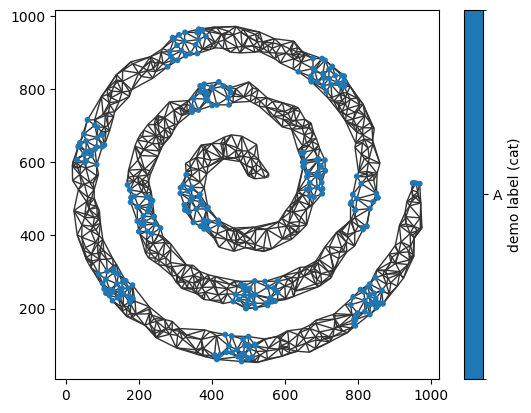

In [3]:
# plot the spatial network with only nodes with label A
sn.utils.plot_spatial_network(spatial_net,nodes_to_plot=node_ids_A,node_label_name='demo label (cat)')

The same approach can be used with negated queries. For example, we can retrieve all nodes whose `demo label (cat)` is **not** `A` and visualise the result.


(<Figure size 640x480 with 2 Axes>, <Axes: >)

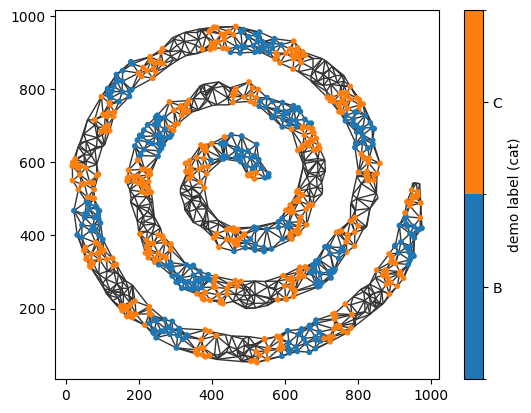

In [4]:
# now let's get all nodes without the label A
node_ids_not_A = sn.utils.query_nodes(spatial_net,node_label_name='demo label (cat)',relation='is not',node_label_value='A')

# plot the spatial network with nodes without label A
sn.utils.plot_spatial_network(spatial_net,nodes_to_plot=node_ids_not_A,node_label_name='demo label (cat)')

We can also query nodes whose labels belong to a specified set of values using the `in` relation. For example, let's retrieve the IDs of all nodes whose `demo label (cat)` is either `A` or `B`.


(<Figure size 640x480 with 2 Axes>, <Axes: >)

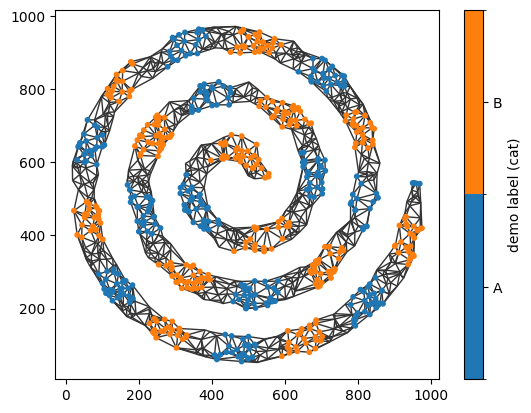

In [5]:
# querying using lists of categories
node_ids_A_or_B = sn.utils.query_nodes(spatial_net,node_label_name='demo label (cat)',relation='in',node_label_value=['A','B'])

# plot the spatial network with only nodes with label A
sn.utils.plot_spatial_network(spatial_net,nodes_to_plot=node_ids_A_or_B,node_label_name='demo label (cat)')

The same functionality works with continous labels. We'll add continuous label to our spatial network next.

(<Figure size 640x480 with 2 Axes>, <Axes: >)

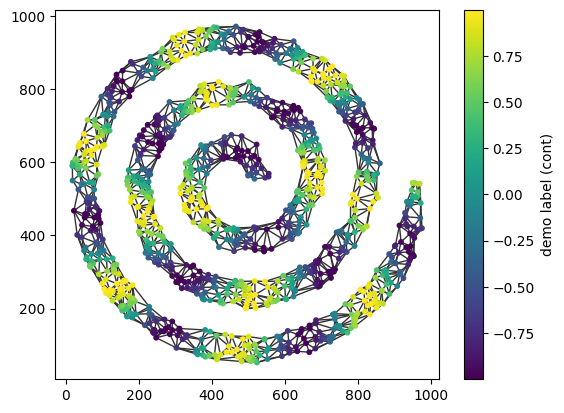

In [6]:
# extract the categorical labels 
cont_labels = spiral_data['Marker (continuous)']

# add the categorical labels to the network
sn.utils.add_node_labels(spatial_net,labels=cont_labels,node_label_name='demo label (cont)')

# plot the spatial network with nodes colored by the demo labels 
sn.utils.plot_spatial_network(spatial_net,node_label_name='demo label (cont)')

Now, for example, we can identify all nodes greater than a specified value.

Text(0.5, 1.0, 'All nodes with demo label (cont) > 0.5')

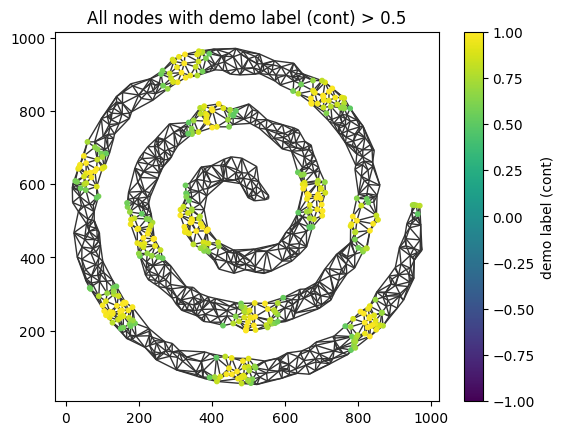

In [7]:
# query all nodes with label 'demo label (cont)'  greater than 0.5
node_high = sn.utils.query_nodes(spatial_net,node_label_name='demo label (cont)',relation='>',node_label_value=0.5)

# plot the spatial network with nodes colored by the demo labels 
fig,ax=sn.utils.plot_spatial_network(spatial_net,node_label_name='demo label (cont)',nodes_to_plot=node_high,scatter_kwargs=dict(vmin=-1,vmax=1))
ax.set_title('All nodes with demo label (cont) > 0.5')

`query_nodes()` supports a wide range of comparison relations, providing a flexible way to identify subsets of nodes based on their labels or attributes. The resulting node IDs can then be used throughout SpaceNet for downstream analyses, filtering operations, or constructing spatial subnetworks.

For a complete description of the available query relations and functionality, see the `query_nodes()` documentation.

